### Stack: Python, LangChain, LangGraph, LangSmith, Groq, Pinecone, Pydantic

This notebook uses **Pinecone as the persistent vector database** for policy RAG.


### Architecture

```text
Claim
  ↓
Input validation / guardrails
  ↓
LangGraph workflow
  ├── Policy RAG → Pinecone
  ├── Receipt checker
  ├── Category-limit checker
  ├── Approval-threshold checker
  └── Timeliness checker
  ↓
Deterministic rule evaluation
  ├── clear result → finalizer
  └── exception/uncertainty → Manual Review / HITL
  ↓
Exact structured JSON
  ↓
Dashboard + LangSmith audit/trace
```

## 1. installing dependencies

In [1]:
! pip install -q langchain langgraph langsmith langchain-community langchain-groq langchain-huggingface langchain-pinecone pinecone pymupdf pydantic python-dotenv pandas matplotlib plotly ipywidgets


# 2. importing necessary libraries and environmental variables

In [2]:
import os
import re
import json
from pathlib import Path
from datetime import datetime
import pymupdf

import pandas as pd
import matplotlib.pyplot as plt

from dotenv import load_dotenv
load_dotenv()

GROQ_API_KEY = os.getenv("GROQ_API_KEY")
MODEL= os.getenv("MODEL")
LANGSMITH_API_KEY = os.getenv("LANGSMITH_API_KEY")

print("Groq configured:", bool(GROQ_API_KEY))
print("LangSmith configured:", bool(LANGSMITH_API_KEY))
print("MODEL:", bool(MODEL))

Groq configured: True
LangSmith configured: True
MODEL: True


# 2. Extracting the policy document from the given pdf using PyMuPDF (fast retrieval)

In [3]:
from pathlib import Path
import pymupdf

PDF_PATH = Path("GenAI_Developer_Candidate_Assignment_Travel_Reimbursement_.pdf")

def extract_policy_page(pdf_path, page_index=2):
    pdf_path = Path(pdf_path)
    if not pdf_path.exists():
        raise FileNotFoundError(pdf_path)
    
    with pymupdf.open(pdf_path) as doc:
        return doc[page_index].get_text("text")

if PDF_PATH.exists():
    extracted_policy_text = extract_policy_page(PDF_PATH, page_index=2)
    print(extracted_policy_text[:6000])
else:
    extracted_policy_text = None
    print("PDF not found beside notebook. Using the embedded policy rules below.")


 
AI Developer Assignment - Travel Reimbursement Approval Agent 
Classification: Public
Appendix A — Travel Reimbursement Policy 
Mock policy for this assignment. No real company or employee data. Every rule has a stable id (POL-*) you 
should cite in your output where relevant. 
1. Eligible & Ineligible Categories 
POL-CAT-01 — Eligible categories — Reimbursable when incurred for a documented business purpose: 
• Airfare (economy class only — see POL-AIR-01) 
• Lodging (hotel room charges) 
• Meals (subject to per-diem limits — see POL-PD-01) 
• Ground transport (taxi, rideshare, train, rental car, parking) 
• Conference / registration fees 
POL-CAT-02 — Ineligible items — Never reimbursable; rejected (deducted in full): 
• Alcohol and minibar charges 
• Spa, gym, and personal entertainment 
• In-room movies, personal shopping, gifts 
• Traffic fines, penalties, and late fees 
• Any personal (non-business) expense 
2. Per-Diem & Category Limits 
POL-PD-01 — Meals — Maximum $75 per day

# 3. Extracting all the policies from above extracted content and converting into langchain document so that we can use it for RAG

In [4]:
POLICY_PATTERN = re.compile(
    r"(POL-[A-Z]+-\d+)\s*[—–-]\s*(.*?)(?=\nPOL-[A-Z]+-\d+\s*[—–-]|\Z)",
    re.DOTALL
)
matches = POLICY_PATTERN.findall(extracted_policy_text)

def clean_text(text):
    text = re.sub(r"\s+", " ", text)
    return text.strip()

cleaned_rules = []

for policy_id, text in matches:
    cleaned_rules.append({
        "policy_id": policy_id,
        "text": clean_text(text)
    })

SECTION_MAP = {
    "POL-CAT": "Eligible & Ineligible Categories",
    "POL-PD": "Per-Diem & Category Limits",
    "POL-AIR": "Airfare Class",
    "POL-RCT": "Receipt Rules",
    "POL-APR": "Approval Thresholds",
    "POL-TIME": "Timeliness",
}

for rule in cleaned_rules:
    prefix = rule["policy_id"].rsplit("-", 1)[0]
    rule["section"] = SECTION_MAP.get(prefix, "Unknown")
    rule["page"] = 3   

from langchain_core.documents import Document

policy_documents = []

for rule in cleaned_rules:

    document = Document(
        page_content=(
            f"Policy ID: {rule['policy_id']}\n"
            f"Section: {rule['section']}\n"
            f"Rule: {rule['text']}"
        ),
        metadata={
            "policy_id": rule["policy_id"],
            "section": rule["section"],
            "source": "Travel Reimbursement Policy — Appendix A",
            "page": rule["page"],
        }
    )

    policy_documents.append(document)    
    
policy_documents    

[Document(metadata={'policy_id': 'POL-CAT-01', 'section': 'Eligible & Ineligible Categories', 'source': 'Travel Reimbursement Policy — Appendix A', 'page': 3}, page_content='Policy ID: POL-CAT-01\nSection: Eligible & Ineligible Categories\nRule: Eligible categories — Reimbursable when incurred for a documented business purpose: • Airfare (economy class only — see POL-AIR-01) • Lodging (hotel room charges) • Meals (subject to per-diem limits — see POL-PD-01) • Ground transport (taxi, rideshare, train, rental car, parking) • Conference / registration fees'),
 Document(metadata={'policy_id': 'POL-CAT-02', 'section': 'Eligible & Ineligible Categories', 'source': 'Travel Reimbursement Policy — Appendix A', 'page': 3}, page_content='Policy ID: POL-CAT-02\nSection: Eligible & Ineligible Categories\nRule: Ineligible items — Never reimbursable; rejected (deducted in full): • Alcohol and minibar charges • Spa, gym, and personal entertainment • In-room movies, personal shopping, gifts • Traffic f

# 4. Extracting the sample claims from the document

In [5]:
# ============================================================
# Extract and Parse Five Sample Claims from Appendix B
# RECTIFIED VERSION
# ============================================================
import re
import pymupdf
import pprint

PDF_PATH = "GenAI_Developer_Candidate_Assignment_Travel_Reimbursement_.pdf"

with pymupdf.open(PDF_PATH) as doc:
    extracted_text = "\n".join(page.get_text("text") for page in doc)

print("PDF text extracted successfully.")
print(f"Total characters extracted: {len(extracted_text):,}")

appendix_b_match = re.search(
    r"Appendix B\s*[—–-]\s*Sample Claims to Evaluate",
    extracted_text,
    flags=re.IGNORECASE,
)
if not appendix_b_match:
    raise ValueError("Appendix B — Sample Claims to Evaluate was not found.")
appendix_b_text = extracted_text[appendix_b_match.start():]
print("\nAppendix B located successfully.")
print("-" * 80)

claim_blocks = re.split(r"(?=CLM-\d+\s*[—–-])", appendix_b_text, flags=re.IGNORECASE)
claim_blocks = [
    block.strip() for block in claim_blocks
    if re.search(r"\bCLM-\d+\b", block, flags=re.IGNORECASE)
]
print(f"Number of claim blocks found: {len(claim_blocks)}")

expected_claim_ids = {"CLM-001", "CLM-002", "CLM-003", "CLM-004", "CLM-005"}
actual_claim_ids = {
    re.search(r"\b(CLM-\d+)\b", block, flags=re.IGNORECASE).group(1).upper()
    for block in claim_blocks
}
if actual_claim_ids != expected_claim_ids:
    raise ValueError(
        "Claim ID validation failed.\n"
        f"Expected: {sorted(expected_claim_ids)}\n"
        f"Found:    {sorted(actual_claim_ids)}"
    )
print("All five expected claim IDs were found.")

CLAIM_CATEGORIES = {
    "airfare", "lodging", "meals", "conference_fees", "spa", "minibar", "ground_transport"
}

def parse_claim_header(claim_text: str) -> dict:
    claim_id_match = re.search(r"\b(CLM-\d+)\b", claim_text, flags=re.IGNORECASE)
    employee_match = re.search(r"Employee:\s*(.*?)\s*·", claim_text, flags=re.IGNORECASE)
    trip_match = re.search(
        r"Trip:\s*(\d{4}-\d{2}-\d{2})\s*to\s*(\d{4}-\d{2}-\d{2})",
        claim_text, flags=re.IGNORECASE
    )
    submitted_match = re.search(r"Submitted:\s*(\d{4}-\d{2}-\d{2})", claim_text, flags=re.IGNORECASE)
    if not claim_id_match:
        raise ValueError("Claim ID could not be extracted.")
    if not employee_match:
        raise ValueError(f"Employee could not be extracted for {claim_id_match.group(1)}.")
    if not trip_match:
        raise ValueError(f"Trip dates could not be extracted for {claim_id_match.group(1)}.")
    if not submitted_match:
        raise ValueError(f"Submission date could not be extracted for {claim_id_match.group(1)}.")
    return {
        "claim_id": claim_id_match.group(1).upper(),
        "employee": employee_match.group(1).strip(),
        "trip_start": trip_match.group(1),
        "trip_end": trip_match.group(2),
        "submitted": submitted_match.group(1),
    }

def parse_claim_items(claim_text: str) -> list:
    lines = [line.strip() for line in claim_text.splitlines() if line.strip()]
    items = []
    current_category = None
    current_description = []
    amount_receipt_pattern = re.compile(r"(\d+(?:\.\d{2})?)\s+(Yes|No)\s*$", flags=re.IGNORECASE)

    def current_item_is_complete() -> bool:
        return bool(amount_receipt_pattern.search(" ".join(current_description).strip()))

    def save_current_item() -> None:
        nonlocal current_category, current_description
        if current_category is None:
            return
        description = " ".join(current_description).strip()
        match = amount_receipt_pattern.search(description)
        if not match:
            raise ValueError(
                f"Could not extract amount/receipt for category '{current_category}'.\n"
                f"Collected text: {description}"
            )
        items.append({
            "category": current_category,
            "description": description[:match.start()].strip(),
            "amount": float(match.group(1)),
            "receipt": match.group(2).lower() == "yes",
        })
        current_category = None
        current_description = []

    for line in lines:
        lower_line = line.lower()
        if re.match(r"^CLM-\d+", line, flags=re.IGNORECASE):
            continue
        if lower_line.startswith(("employee:", "trip:", "submitted:", "category description", "total claimed:")):
            continue

        category_found = None
        remainder = None
        for category in CLAIM_CATEGORIES:
            match = re.match(rf"^{re.escape(category)}(?:\s+|$)", line, flags=re.IGNORECASE)
            if match:
                category_found = category
                remainder = line[match.end():].strip()
                break

        if category_found is not None:
            if current_category is not None:
                if current_item_is_complete():
                    save_current_item()
                else:
                    # Wrapped description: the category word is part of the previous item.
                    current_description.append(line)
                    continue
            current_category = category_found
            current_description = []
            if remainder:
                current_description.append(remainder)
        elif current_category is not None:
            current_description.append(line)

    save_current_item()
    return items

def parse_claim(claim_text: str) -> dict:
    """Return one complete claim dictionary expected by downstream cells.

    The previous implementation returned only a list of items. Downstream code then
    accessed x["claim_id"], causing a list/dict mismatch. This version combines the
    header, parsed items, and total_claimed. It also handles wrapped CLM-004 airfare text.
    """
    header = parse_claim_header(claim_text)
    items = parse_claim_items(claim_text)
    if not items:
        raise ValueError(f"No expense items were found for {header['claim_id']}.")
    return {
        **header,
        "items": items,
        "total_claimed": round(sum(item["amount"] for item in items), 2),
    }

claims = sorted([parse_claim(block) for block in claim_blocks], key=lambda x: x["claim_id"])
assert all(isinstance(claim, dict) for claim in claims)
assert [claim["claim_id"] for claim in claims] == sorted(expected_claim_ids)
assert all(claim["items"] for claim in claims)

print("\nClaims parsed successfully.")
for claim in claims:
    print(f"{claim['claim_id']}: {len(claim['items'])} item(s), total=${claim['total_claimed']:.2f}")
pprint.pp(claims, sort_dicts=False)


PDF text extracted successfully.
Total characters extracted: 10,955

Appendix B located successfully.
--------------------------------------------------------------------------------
Number of claim blocks found: 5
All five expected claim IDs were found.

Claims parsed successfully.
CLM-001: 4 item(s), total=$1110.00
CLM-002: 2 item(s), total=$380.00
CLM-003: 3 item(s), total=$940.00
CLM-004: 2 item(s), total=$3000.00
CLM-005: 1 item(s), total=$220.00
[{'claim_id': 'CLM-001',
  'employee': 'A. Rivera',
  'trip_start': '2026-06-10',
  'trip_end': '2026-06-12',
  'submitted': '2026-06-20',
  'items': [{'category': 'airfare',
             'description': 'Round-trip economy airfare',
             'amount': 420.0,
             'receipt': True},
            {'category': 'lodging',
             'description': 'Hotel, 2 nights @ $180',
             'amount': 360.0,
             'receipt': True},
            {'category': 'meals',
             'description': 'Meals, 3 days @ ~$60/day',
         

In [6]:
# Claims are already parsed by the corrected parse_claim() function above.
claims = sorted(claims, key=lambda x: x["claim_id"])
print("Parsed claim IDs:", [c["claim_id"] for c in claims])
pprint.pp(claims, sort_dicts=False)


Parsed claim IDs: ['CLM-001', 'CLM-002', 'CLM-003', 'CLM-004', 'CLM-005']
[{'claim_id': 'CLM-001',
  'employee': 'A. Rivera',
  'trip_start': '2026-06-10',
  'trip_end': '2026-06-12',
  'submitted': '2026-06-20',
  'items': [{'category': 'airfare',
             'description': 'Round-trip economy airfare',
             'amount': 420.0,
             'receipt': True},
            {'category': 'lodging',
             'description': 'Hotel, 2 nights @ $180',
             'amount': 360.0,
             'receipt': True},
            {'category': 'meals',
             'description': 'Meals, 3 days @ ~$60/day',
             'amount': 180.0,
             'receipt': True},
            {'category': 'conference_fees',
             'description': 'Conference registration',
             'amount': 150.0,
             'receipt': True}],
  'total_claimed': 1110.0},
 {'claim_id': 'CLM-002',
  'employee': 'B. Osei',
  'trip_start': '2026-06-14',
  'trip_end': '2026-06-15',
  'submitted': '2026-06-25',
  'i

# 5. pydantic schema for data validation

In [7]:
# 9. Pydantic input/output schemas
from typing import Literal
from pydantic import BaseModel, Field

DecisionType = Literal["APPROVE","PARTIAL_APPROVE","REJECT","MANUAL_REVIEW"]

class ClaimItem(BaseModel):
    category: str
    description: str
    amount: float = Field(gt=0)
    receipt: bool

class Claim(BaseModel):
    claim_id: str
    employee: str
    trip_start: str
    trip_end: str
    submitted: str
    items: list[ClaimItem]

class ReimbursementDecision(BaseModel):
    claim_id: str
    decision: DecisionType
    approved_amount: float = Field(ge=0)
    deducted_amount: float = Field(ge=0)
    missing_docs: list[str]
    policy_refs: list[str]
    confidence: float = Field(ge=0, le=1)
    explanation: str
    tools_used: list[str]

validated_claims=[Claim.model_validate(c) for c in claims]
print("Validated claims:", len(validated_claims))

Validated claims: 5


# 6. Deterministic business-rule

In [8]:
CATEGORY_LIMITS={"meals":75.0,"lodging":200.0,"ground_transport":50.0}
INELIGIBLE_CATEGORIES={"alcohol","minibar","spa","gym","personal_entertainment","in_room_movies","personal_shopping","gifts","traffic_fines","penalties","late_fees","personal_expense"}

def check_receipts(claim):
    missing=[]
    for item in claim["items"]:
        required=item["amount"]>25 or item["category"] in {"airfare","lodging"}
        if required and not item["receipt"]:
            missing.append(item["category"])
    return {"missing_receipts":missing,"status":"MISSING" if missing else "COMPLETE","policy_refs":["POL-RCT-01","POL-RCT-02"]}

def check_category_limits(claim):
    rows=[]
    for item in claim["items"]:
        cat=item["category"]; amount=float(item["amount"])
        if cat in INELIGIBLE_CATEGORIES:
            approved=0.0; deducted=amount; reason="INELIGIBLE_CATEGORY"
        elif cat in CATEGORY_LIMITS:
            limit=CATEGORY_LIMITS[cat]
            if cat=="lodging":
                m=re.search(r"(\d+)\s*nights?",item["description"].lower()); count=int(m.group(1)) if m else 1; cap=limit*count
            elif cat=="meals":
                m=re.search(r"(\d+)\s*days?",item["description"].lower()); count=int(m.group(1)) if m else 1; cap=limit*count
            else:
                cap=limit
            approved=min(amount,cap); deducted=max(amount-cap,0); reason="WITHIN_LIMIT" if deducted==0 else "LIMIT_EXCEEDED"
        else:
            approved=amount; deducted=0.0; reason="NO_CATEGORY_CAP"
        rows.append({"category":cat,"claimed":amount,"approved":round(approved,2),"deducted":round(deducted,2),"reason":reason})
    return {"items":rows,"approved_total":round(sum(x["approved"] for x in rows),2),"deducted_total":round(sum(x["deducted"] for x in rows),2)}

def check_approval_threshold(total):
    if total<=500: return {"tier":"AUTO_APPROVE","policy_ref":"POL-APR-01"}
    if total<=2000: return {"tier":"MANAGER","policy_ref":"POL-APR-02"}
    return {"tier":"MANUAL_REVIEW","policy_ref":"POL-APR-03"}

def check_submission_window(claim):
    days=(datetime.fromisoformat(claim["submitted"])-datetime.fromisoformat(claim["trip_end"])).days
    return {"days_to_submit":days,"within_window":days<=30,"policy_ref":"POL-TIME-01"}

def check_airfare_exception(claim):
    exceptions=[]
    for item in claim["items"]:
        text=item["description"].lower()
        if item["category"]=="airfare" and ("business" in text or "first" in text):
            exceptions.append({"issue":"business_or_first_class","policy_ref":"POL-AIR-01"})
    return {"exceptions":exceptions}

# 7. Pinecone Vector Database for RAG

We use Pinecone as the managed vector database for the travel reimbursement policy.
The workflow is:

1. Create/load the embedding model.
2. Create the Pinecone index if it does not already exist.
3. Connect through `PineconeVectorStore`.
4. Upsert the extracted policy documents into a dedicated namespace.
5. Build a retriever for semantic policy lookup.


In [9]:
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_pinecone import PineconeVectorStore
from pinecone import Pinecone, ServerlessSpec
import os

# ------------------------------------------------------------
# 1. Embedding model
# ------------------------------------------------------------
embedding = HuggingFaceEmbeddings(
    model_name="BAAI/bge-small-en-v1.5"
)

dimension = len(embedding.embed_query("finding embedding dimension"))
print("Embedding dimension:", dimension)

# ------------------------------------------------------------
# 2. Pinecone configuration
# ------------------------------------------------------------
pinecone_api_key = os.getenv("PINECONE_API_KEY")
if not pinecone_api_key:
    raise ValueError(
        "PINECONE_API_KEY is not set. Add it to your .env file or environment."
    )

pc = Pinecone(api_key=pinecone_api_key)

INDEX_NAME = "travelreimbursementagent"
NAMESPACE = "travel-policy-v1"

# ------------------------------------------------------------
# 3. Create the index only if it does not exist
# ------------------------------------------------------------
if not pc.has_index(INDEX_NAME):
    print(f"Creating Pinecone index: {INDEX_NAME}")
    pc.create_index(
        name=INDEX_NAME,
        dimension=dimension,
        metric="cosine",
        spec=ServerlessSpec(
            cloud="aws",
            region="us-east-1"
        )
    )
else:
    print(f"Pinecone index already exists: {INDEX_NAME}")

# Connect to the index
index = pc.Index(INDEX_NAME)

print("Index:", INDEX_NAME)
print("Namespace:", NAMESPACE)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Embedding dimension: 384
Creating Pinecone index: travelreimbursementagent
Index: travelreimbursementagent
Namespace: travel-policy-v1


In [28]:
# Verify Pinecone index
print(index.describe_index_stats())


{'dimension': 384,
 'index_fullness': 0.0,
 'metric': 'cosine',
 'namespaces': {'travel-policy-v1': {'vector_count': 12}},
 'total_vector_count': 12,
 'vector_type': 'dense'}


# 7.1 Upsert policy documents into Pinecone

The policy documents are stored in a dedicated namespace so that this application
can share the same Pinecone index with other datasets/applications if required.


In [29]:
# ------------------------------------------------------------
# 4. Connect LangChain to Pinecone
# ------------------------------------------------------------
vector_store = PineconeVectorStore(
    index=index,
    embedding=embedding,
    namespace=NAMESPACE
)

# ------------------------------------------------------------
# 5. Upsert policy documents
# ------------------------------------------------------------
# Use stable IDs based on policy_id so rerunning this cell updates the same
# vectors instead of creating uncontrolled duplicates.
document_ids = [doc.metadata["policy_id"] for doc in policy_documents]

vector_store.add_documents(
    documents=policy_documents,
    ids=document_ids
)

print(f"Upserted {len(policy_documents)} policy documents into Pinecone.")
print(index.describe_index_stats())

# ------------------------------------------------------------
# 6. Retriever
# ------------------------------------------------------------
retriever = vector_store.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 4}
)

# Quick retrieval test
test_docs = retriever.invoke("What are the receipt requirements?")
print("\nRetrieval test:")
for d in test_docs:
    print(f"- {d.metadata['policy_id']}: {d.page_content[:250]}...")


Upserted 12 policy documents into Pinecone.
{'dimension': 384,
 'index_fullness': 0.0,
 'metric': 'cosine',
 'namespaces': {'travel-policy-v1': {'vector_count': 12}},
 'total_vector_count': 12,
 'vector_type': 'dense'}

Retrieval test:
- POL-RCT-01: Policy ID: POL-RCT-01
Section: Receipt Rules
Rule: Receipt required above $25 — Any single line item greater than $25 requires an attached, itemized receipt. Airfare and lodging always require a receipt regardless of amount....
- POL-RCT-02: Policy ID: POL-RCT-02
Section: Receipt Rules
Rule: Missing receipt handling — If a receipt is missing for an item that requires one, the item is not silently rejected — the claim is routed to Manual Review so the reviewer can request the receipt. 4. ...
- POL-TIME-01: Policy ID: POL-TIME-01
Section: Timeliness
Rule: Submission window — Claims must be submitted within 30 days of the expense date. Late claims are routed to Manual Review. Decision Guidance (how the rules combine) Approve — every item eligi

# 8. Langchain tools

In [30]:
from langchain_core.tools import tool

@tool
def policy_lookup(query: str) -> str:
    """Retrieve relevant reimbursement policy rules from Pinecone."""
    docs = retriever.invoke(query)
    return "\n\n".join(
        f"[{d.metadata.get('policy_id', 'UNKNOWN')}] {d.page_content}"
        for d in docs
    )

@tool
def receipt_completeness_checker(claim_json: str) -> str:
    """Check required receipts for a JSON claim."""
    return json.dumps(check_receipts(json.loads(claim_json)), indent=2)

@tool
def category_limit_checker(claim_json: str) -> str:
    """Calculate category reimbursement limits and deductions."""
    return json.dumps(check_category_limits(json.loads(claim_json)), indent=2)

@tool
def approval_threshold_checker(total_reimbursable: float) -> str:
    """Determine approval authority from the reimbursable total."""
    return json.dumps(check_approval_threshold(total_reimbursable), indent=2)

@tool
def submission_window_checker(claim_json: str) -> str:
    """Check whether the claim was submitted within 30 days."""
    return json.dumps(check_submission_window(json.loads(claim_json)), indent=2)

TOOLS = [
    policy_lookup,
    receipt_completeness_checker,
    category_limit_checker,
    approval_threshold_checker,
    submission_window_checker,
]

print([t.name for t in TOOLS])


['policy_lookup', 'receipt_completeness_checker', 'category_limit_checker', 'approval_threshold_checker', 'submission_window_checker']


# 9. claim checking using deterministic ways

In [31]:
def collect_evidence(claim):
    receipt = check_receipts(claim)
    limits = check_category_limits(claim)
    threshold = check_approval_threshold(limits["approved_total"])
    timeliness = check_submission_window(claim)
    airfare = check_airfare_exception(claim)

    queries = [
        "eligible and ineligible travel reimbursement categories",
        "meal lodging and ground transport limits",
        "receipt requirements and missing receipts",
        "airfare class rules",
        "approval thresholds and manual review",
        "30 day submission window",
    ]

    unique = {}
    for q in queries:
        for d in retriever.invoke(q):
            policy_id = d.metadata["policy_id"]
            unique[policy_id] = {
                "policy_id": policy_id,
                "text": d.page_content,
            }

    return {
        "receipt_result": receipt,
        "limit_result": limits,
        "threshold_result": threshold,
        "timeliness_result": timeliness,
        "airfare_result": airfare,
        "policy_context": list(unique.values()),
    }


# 10. Langgraph workflow

In [32]:
# 14. LangGraph workflow
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

class ReimbursementState(TypedDict, total=False):
    claim: dict
    evidence: dict
    rule_result: dict
    final_decision: dict
    audit_log: list[dict]
    needs_human: bool
    human_feedback: str

def validate_node(state):
    claim=Claim.model_validate(state["claim"])
    return {"claim":claim.model_dump(),"audit_log":state.get("audit_log",[])+[{"step":"input_validation","status":"passed"}]}

def evidence_node(state):
    evidence=collect_evidence(state["claim"])
    return {"evidence":evidence,"audit_log":state.get("audit_log",[])+[{"step":"evidence_collection","tools":[t.name for t in TOOLS]}]}

def rule_node(state):
    e=state["evidence"]; limits=e["limit_result"]; missing=e["receipt_result"]["missing_receipts"]
    ineligible=[x for x in limits["items"] if x["reason"]=="INELIGIBLE_CATEGORY"]
    if not e["timeliness_result"]["within_window"]:
        decision="MANUAL_REVIEW"; reason="Claim was submitted outside the 30-day submission window."
    elif e["airfare_result"]["exceptions"]:
        decision="MANUAL_REVIEW"; reason="Business/first-class airfare is a policy exception requiring Manual Review."
    elif missing:
        decision="MANUAL_REVIEW"; reason=f"Required receipt(s) are missing for: {', '.join(missing)}."
    elif e["threshold_result"]["tier"]=="MANUAL_REVIEW":
        decision="MANUAL_REVIEW"; reason="Reimbursable amount exceeds the agent's approval authority."
    elif ineligible and limits["approved_total"]==0:
        decision="REJECT"; reason="All claimed items are explicitly ineligible under the policy."
    elif limits["deducted_total"]>0:
        decision="PARTIAL_APPROVE"; reason="One or more eligible categories exceed their policy limits."
    else:
        decision="APPROVE"; reason="All items are eligible, required receipts are present, limits are satisfied, and the approval threshold is satisfied."
    return {"rule_result":{"decision":decision,"reason":reason},"needs_human":decision=="MANUAL_REVIEW","audit_log":state.get("audit_log",[])+[{"step":"rule_evaluation","decision":decision,"reason":reason}]}

def route(state):
    return "human_review" if state.get("needs_human") else "finalize"

def human_review_simulation(state):
    feedback=state.get("human_feedback") or "Manual Review required; reviewer action pending."
    return {"human_feedback":feedback,"audit_log":state.get("audit_log",[])+[{"step":"human_review","status":"required","feedback":feedback}]}

def finalize_node(state):
    e=state["evidence"]; r=state["rule_result"]; decision=r["decision"]
    approved=0.0 if decision=="MANUAL_REVIEW" else e["limit_result"]["approved_total"]
    deducted=0.0 if decision=="MANUAL_REVIEW" else e["limit_result"]["deducted_total"]
    refs=sorted({x["policy_id"] for x in e["policy_context"]})
    confidence=0.55 if decision=="MANUAL_REVIEW" else (0.95 if decision=="PARTIAL_APPROVE" else 0.98)
    result=ReimbursementDecision(claim_id=state["claim"]["claim_id"],decision=decision,approved_amount=round(approved,2),deducted_amount=round(deducted,2),missing_docs=e["receipt_result"]["missing_receipts"],policy_refs=refs,confidence=confidence,explanation=r["reason"],tools_used=[t.name for t in TOOLS])
    return {"final_decision":result.model_dump(),"audit_log":state.get("audit_log",[])+[{"step":"finalization","decision":result.model_dump()}]}

builder=StateGraph(ReimbursementState)
builder.add_node("validate",validate_node); builder.add_node("evidence",evidence_node); builder.add_node("rules",rule_node); builder.add_node("human_review",human_review_simulation); builder.add_node("finalize",finalize_node)
builder.add_edge(START,"validate"); builder.add_edge("validate","evidence"); builder.add_edge("evidence","rules")
builder.add_conditional_edges("rules",route,{"human_review":"human_review","finalize":"finalize"})
builder.add_edge("human_review","finalize"); builder.add_edge("finalize",END)
graph=builder.compile()
print("LangGraph compiled")

LangGraph compiled


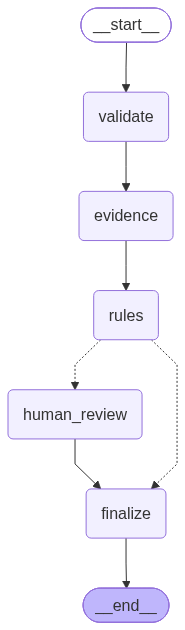

In [33]:
graph

# 11. HITL / Manual Review : using `interrupt()` plus a checkpointer 

In [34]:

from langgraph.types import interrupt

def human_review_with_interrupt(state):
    payload={
        "claim_id":state["claim"]["claim_id"],
        "reason":state["rule_result"]["reason"],
        "policy_refs":sorted({x["policy_id"] for x in state["evidence"]["policy_context"]}),
        "requested_action":"Approve / Reject / Request Receipt / Continue Manual Review",
    }
    response=interrupt(payload)
    return {"human_feedback":json.dumps(response),"audit_log":state.get("audit_log",[])+[{"step":"human_review","response":response}]}

print("True interrupt-based HITL node defined.")

True interrupt-based HITL node defined.


# 12. running claims

In [35]:
all_results=[]
all_audits={}
for claim in claims:
    state=graph.invoke({"claim":claim,"audit_log":[]})
    all_results.append(state["final_decision"])
    all_audits[claim["claim_id"]]=state["audit_log"]
print(json.dumps(all_results,indent=2))

[
  {
    "claim_id": "CLM-001",
    "decision": "APPROVE",
    "approved_amount": 1110.0,
    "deducted_amount": 0.0,
    "missing_docs": [],
    "policy_refs": [
      "POL-AIR-01",
      "POL-APR-01",
      "POL-APR-02",
      "POL-APR-03",
      "POL-CAT-01",
      "POL-CAT-02",
      "POL-PD-01",
      "POL-PD-02",
      "POL-PD-03",
      "POL-RCT-01",
      "POL-RCT-02",
      "POL-TIME-01"
    ],
    "confidence": 0.98,
    "explanation": "All items are eligible, required receipts are present, limits are satisfied, and the approval threshold is satisfied.",
    "tools_used": [
      "policy_lookup",
      "receipt_completeness_checker",
      "category_limit_checker",
      "approval_threshold_checker",
      "submission_window_checker"
    ]
  },
  {
    "claim_id": "CLM-002",
    "decision": "REJECT",
    "approved_amount": 0.0,
    "deducted_amount": 380.0,
    "missing_docs": [],
    "policy_refs": [
      "POL-AIR-01",
      "POL-APR-01",
      "POL-APR-02",
      "POL-APR

## 13. Groq / GenAI layer (LLM)

In [36]:
# 18. Groq explanation layer
from langchain_groq import ChatGroq

if GROQ_API_KEY:
    llm=ChatGroq(model=MODEL,temperature=0,api_key=GROQ_API_KEY)
else:
    llm=None

SYSTEM_PROMPT="""You are a Travel Reimbursement Approval Agent. Use only supplied policy evidence and deterministic results. Never invent policy IDs or limits. Never change deterministic amounts. Preserve MANUAL_REVIEW for exceptions or missing required information. Write a concise audit-friendly explanation and cite relevant POL-* IDs. Do not expose hidden chain-of-thought."""

def generate_explanation(claim,evidence,rule_result):
    if llm is None:
        return rule_result["reason"]
    prompt=f"""{SYSTEM_PROMPT}\n\nCLAIM:\n{json.dumps(claim,indent=2)}\n\nPOLICY EVIDENCE:\n{json.dumps(evidence,indent=2)}\n\nDETERMINISTIC DECISION:\n{json.dumps(rule_result,indent=2)}\n\nWrite only a concise business explanation. Do not change the decision or amounts."""
    return llm.invoke(prompt).content

print("Groq layer:","enabled" if llm else "fallback mode")

Groq layer: enabled


# 14. Applying Gen AI

In [37]:
for result in all_results:
    claim=next(c for c in claims if c["claim_id"]==result["claim_id"])
    state=graph.invoke({"claim":claim,"audit_log":[]})
    result["explanation"]=generate_explanation(claim,state["evidence"],state["rule_result"])
print(json.dumps(all_results,indent=2))

[
  {
    "claim_id": "CLM-001",
    "decision": "APPROVE",
    "approved_amount": 1110.0,
    "deducted_amount": 0.0,
    "missing_docs": [],
    "policy_refs": [
      "POL-AIR-01",
      "POL-APR-01",
      "POL-APR-02",
      "POL-APR-03",
      "POL-CAT-01",
      "POL-CAT-02",
      "POL-PD-01",
      "POL-PD-02",
      "POL-PD-03",
      "POL-RCT-01",
      "POL-RCT-02",
      "POL-TIME-01"
    ],
    "confidence": 0.98,
    "explanation": "**Decision:** APPROVE  \n**Reason:** All claimed items are eligible under POL\u2011CAT\u201101, receipts are present for every line (POL\u2011RCT\u201101, POL\u2011RCT\u201102), and each category stays within its per\u2011diem limits (POL\u2011PD\u201102 for lodging, POL\u2011PD\u201101 for meals). No deductions are required, and the total reimbursable amount ($1,110) falls within the Manager approval tier (POL\u2011APR\u201102). The claim was submitted within the 30\u2011day window (POL\u2011TIME\u201101). Therefore the claim meets all polic

# 15. output guardrails

In [38]:
EXPECTED_FIELDS={"claim_id","decision","approved_amount","deducted_amount","missing_docs","policy_refs","confidence","explanation","tools_used"}
ALLOWED={"APPROVE","PARTIAL_APPROVE","REJECT","MANUAL_REVIEW"}
for result in all_results:
    assert set(result)==EXPECTED_FIELDS
    assert result["decision"] in ALLOWED
    assert result["approved_amount"]>=0 and result["deducted_amount"]>=0
    assert 0<=result["confidence"]<=1
    assert all(ref.startswith("POL-") for ref in result["policy_refs"])
    if result["decision"]=="MANUAL_REVIEW":
        assert result["approved_amount"]==0 and result["deducted_amount"]==0
print("Output guardrails passed.")

Output guardrails passed.


# 16. Evaluate all five claims

In [39]:
expected={"CLM-001":"APPROVE","CLM-002":"REJECT","CLM-003":"PARTIAL_APPROVE","CLM-004":"MANUAL_REVIEW","CLM-005":"MANUAL_REVIEW"}
evaluation_df=pd.DataFrame([{"claim_id":r["claim_id"],"expected":expected[r["claim_id"]],"actual":r["decision"],"match":expected[r["claim_id"]]==r["decision"]} for r in all_results])
display(evaluation_df)
print(f"Decision accuracy: {evaluation_df['match'].mean():.1%}")

,claim_id,expected,actual,match
0,CLM-001,APPROVE,APPROVE,True
1,CLM-002,REJECT,REJECT,True
2,CLM-003,PARTIAL_APPROVE,PARTIAL_APPROVE,True
3,CLM-004,MANUAL_REVIEW,MANUAL_REVIEW,True
4,CLM-005,MANUAL_REVIEW,MANUAL_REVIEW,True


Decision accuracy: 100.0%


# 17. Dashboard

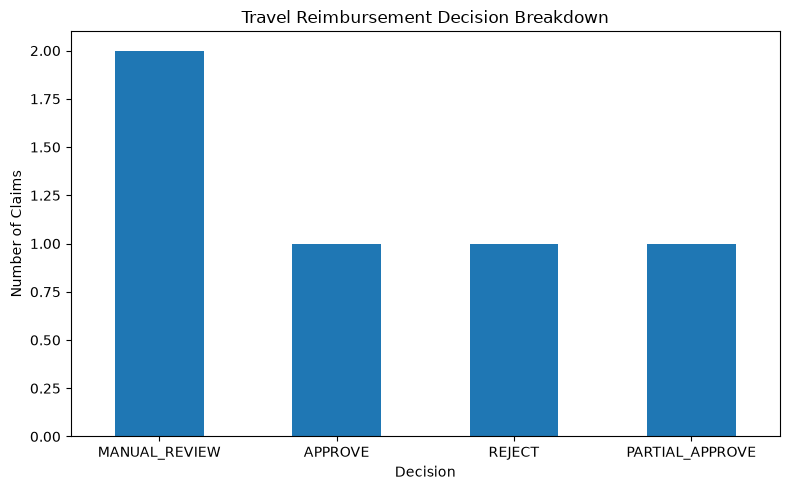

,Metric,Value
0,Total Claims,5.0
1,Approved Claims,1.0
2,Partial Approvals,1.0
3,Rejected Claims,1.0
4,Manual Review Claims,2.0
5,Total Approved Amount,1950.0
6,Total Deducted Amount,480.0


In [40]:
import matplotlib.pyplot as plt
results_df=pd.DataFrame(all_results)
counts=results_df["decision"].value_counts()
ax=counts.plot(kind="bar",figsize=(8,5),title="Travel Reimbursement Decision Breakdown")
ax.set_xlabel("Decision"); ax.set_ylabel("Number of Claims"); plt.xticks(rotation=0); plt.tight_layout(); plt.show()
summary=pd.DataFrame({"Metric":["Total Claims","Approved Claims","Partial Approvals","Rejected Claims","Manual Review Claims","Total Approved Amount","Total Deducted Amount"],"Value":[len(results_df),(results_df.decision=="APPROVE").sum(),(results_df.decision=="PARTIAL_APPROVE").sum(),(results_df.decision=="REJECT").sum(),(results_df.decision=="MANUAL_REVIEW").sum(),results_df.approved_amount.sum(),results_df.deducted_amount.sum()]})
display(summary)

In [41]:
display(results_df[["claim_id","decision","approved_amount","deducted_amount","missing_docs","confidence"]])

,claim_id,decision,approved_amount,deducted_amount,missing_docs,confidence
0,CLM-001,APPROVE,1110.0,0.0,[],0.98
1,CLM-002,REJECT,0.0,380.0,[],0.98
2,CLM-003,PARTIAL_APPROVE,840.0,100.0,[],0.95
3,CLM-004,MANUAL_REVIEW,0.0,0.0,[lodging],0.55
4,CLM-005,MANUAL_REVIEW,0.0,0.0,[meals],0.55


# 18. audit trail for each claim

In [42]:

for claim_id,audit in all_audits.items():
    print("="*80); print(claim_id); print(json.dumps(audit,indent=2))

CLM-001
[
  {
    "step": "input_validation",
    "status": "passed"
  },
  {
    "step": "evidence_collection",
    "tools": [
      "policy_lookup",
      "receipt_completeness_checker",
      "category_limit_checker",
      "approval_threshold_checker",
      "submission_window_checker"
    ]
  },
  {
    "step": "rule_evaluation",
    "decision": "APPROVE",
    "reason": "All items are eligible, required receipts are present, limits are satisfied, and the approval threshold is satisfied."
  },
  {
    "step": "finalization",
    "decision": {
      "claim_id": "CLM-001",
      "decision": "APPROVE",
      "approved_amount": 1110.0,
      "deducted_amount": 0.0,
      "missing_docs": [],
      "policy_refs": [
        "POL-AIR-01",
        "POL-APR-01",
        "POL-APR-02",
        "POL-APR-03",
        "POL-CAT-01",
        "POL-CAT-02",
        "POL-PD-01",
        "POL-PD-02",
        "POL-PD-03",
        "POL-RCT-01",
        "POL-RCT-02",
        "POL-TIME-01"
      ],
      "

## 19. LangSmith: for observability 

In [43]:
print("Tracing:",os.getenv("LANGSMITH_TRACING"))
print("Project:",os.getenv("LANGSMITH_PROJECT"))
print("LangSmith key configured:",bool(os.getenv("LANGSMITH_API_KEY")))

Tracing: true
Project: Travel_Reimbursement_Agent
LangSmith key configured: True


# 20. Required JSON output

In [44]:
print(json.dumps(all_results,indent=2))

[
  {
    "claim_id": "CLM-001",
    "decision": "APPROVE",
    "approved_amount": 1110.0,
    "deducted_amount": 0.0,
    "missing_docs": [],
    "policy_refs": [
      "POL-AIR-01",
      "POL-APR-01",
      "POL-APR-02",
      "POL-APR-03",
      "POL-CAT-01",
      "POL-CAT-02",
      "POL-PD-01",
      "POL-PD-02",
      "POL-PD-03",
      "POL-RCT-01",
      "POL-RCT-02",
      "POL-TIME-01"
    ],
    "confidence": 0.98,
    "explanation": "**Decision:** APPROVE  \n**Reason:** All claimed items are eligible under POL\u2011CAT\u201101, receipts are present for every line (POL\u2011RCT\u201101, POL\u2011RCT\u201102), and each category stays within its per\u2011diem limits (POL\u2011PD\u201102 for lodging, POL\u2011PD\u201101 for meals). No deductions are required, and the total reimbursable amount ($1,110) falls within the Manager approval tier (POL\u2011APR\u201102). The claim was submitted within the 30\u2011day window (POL\u2011TIME\u201101). Therefore the claim meets all polic

## Langsmith

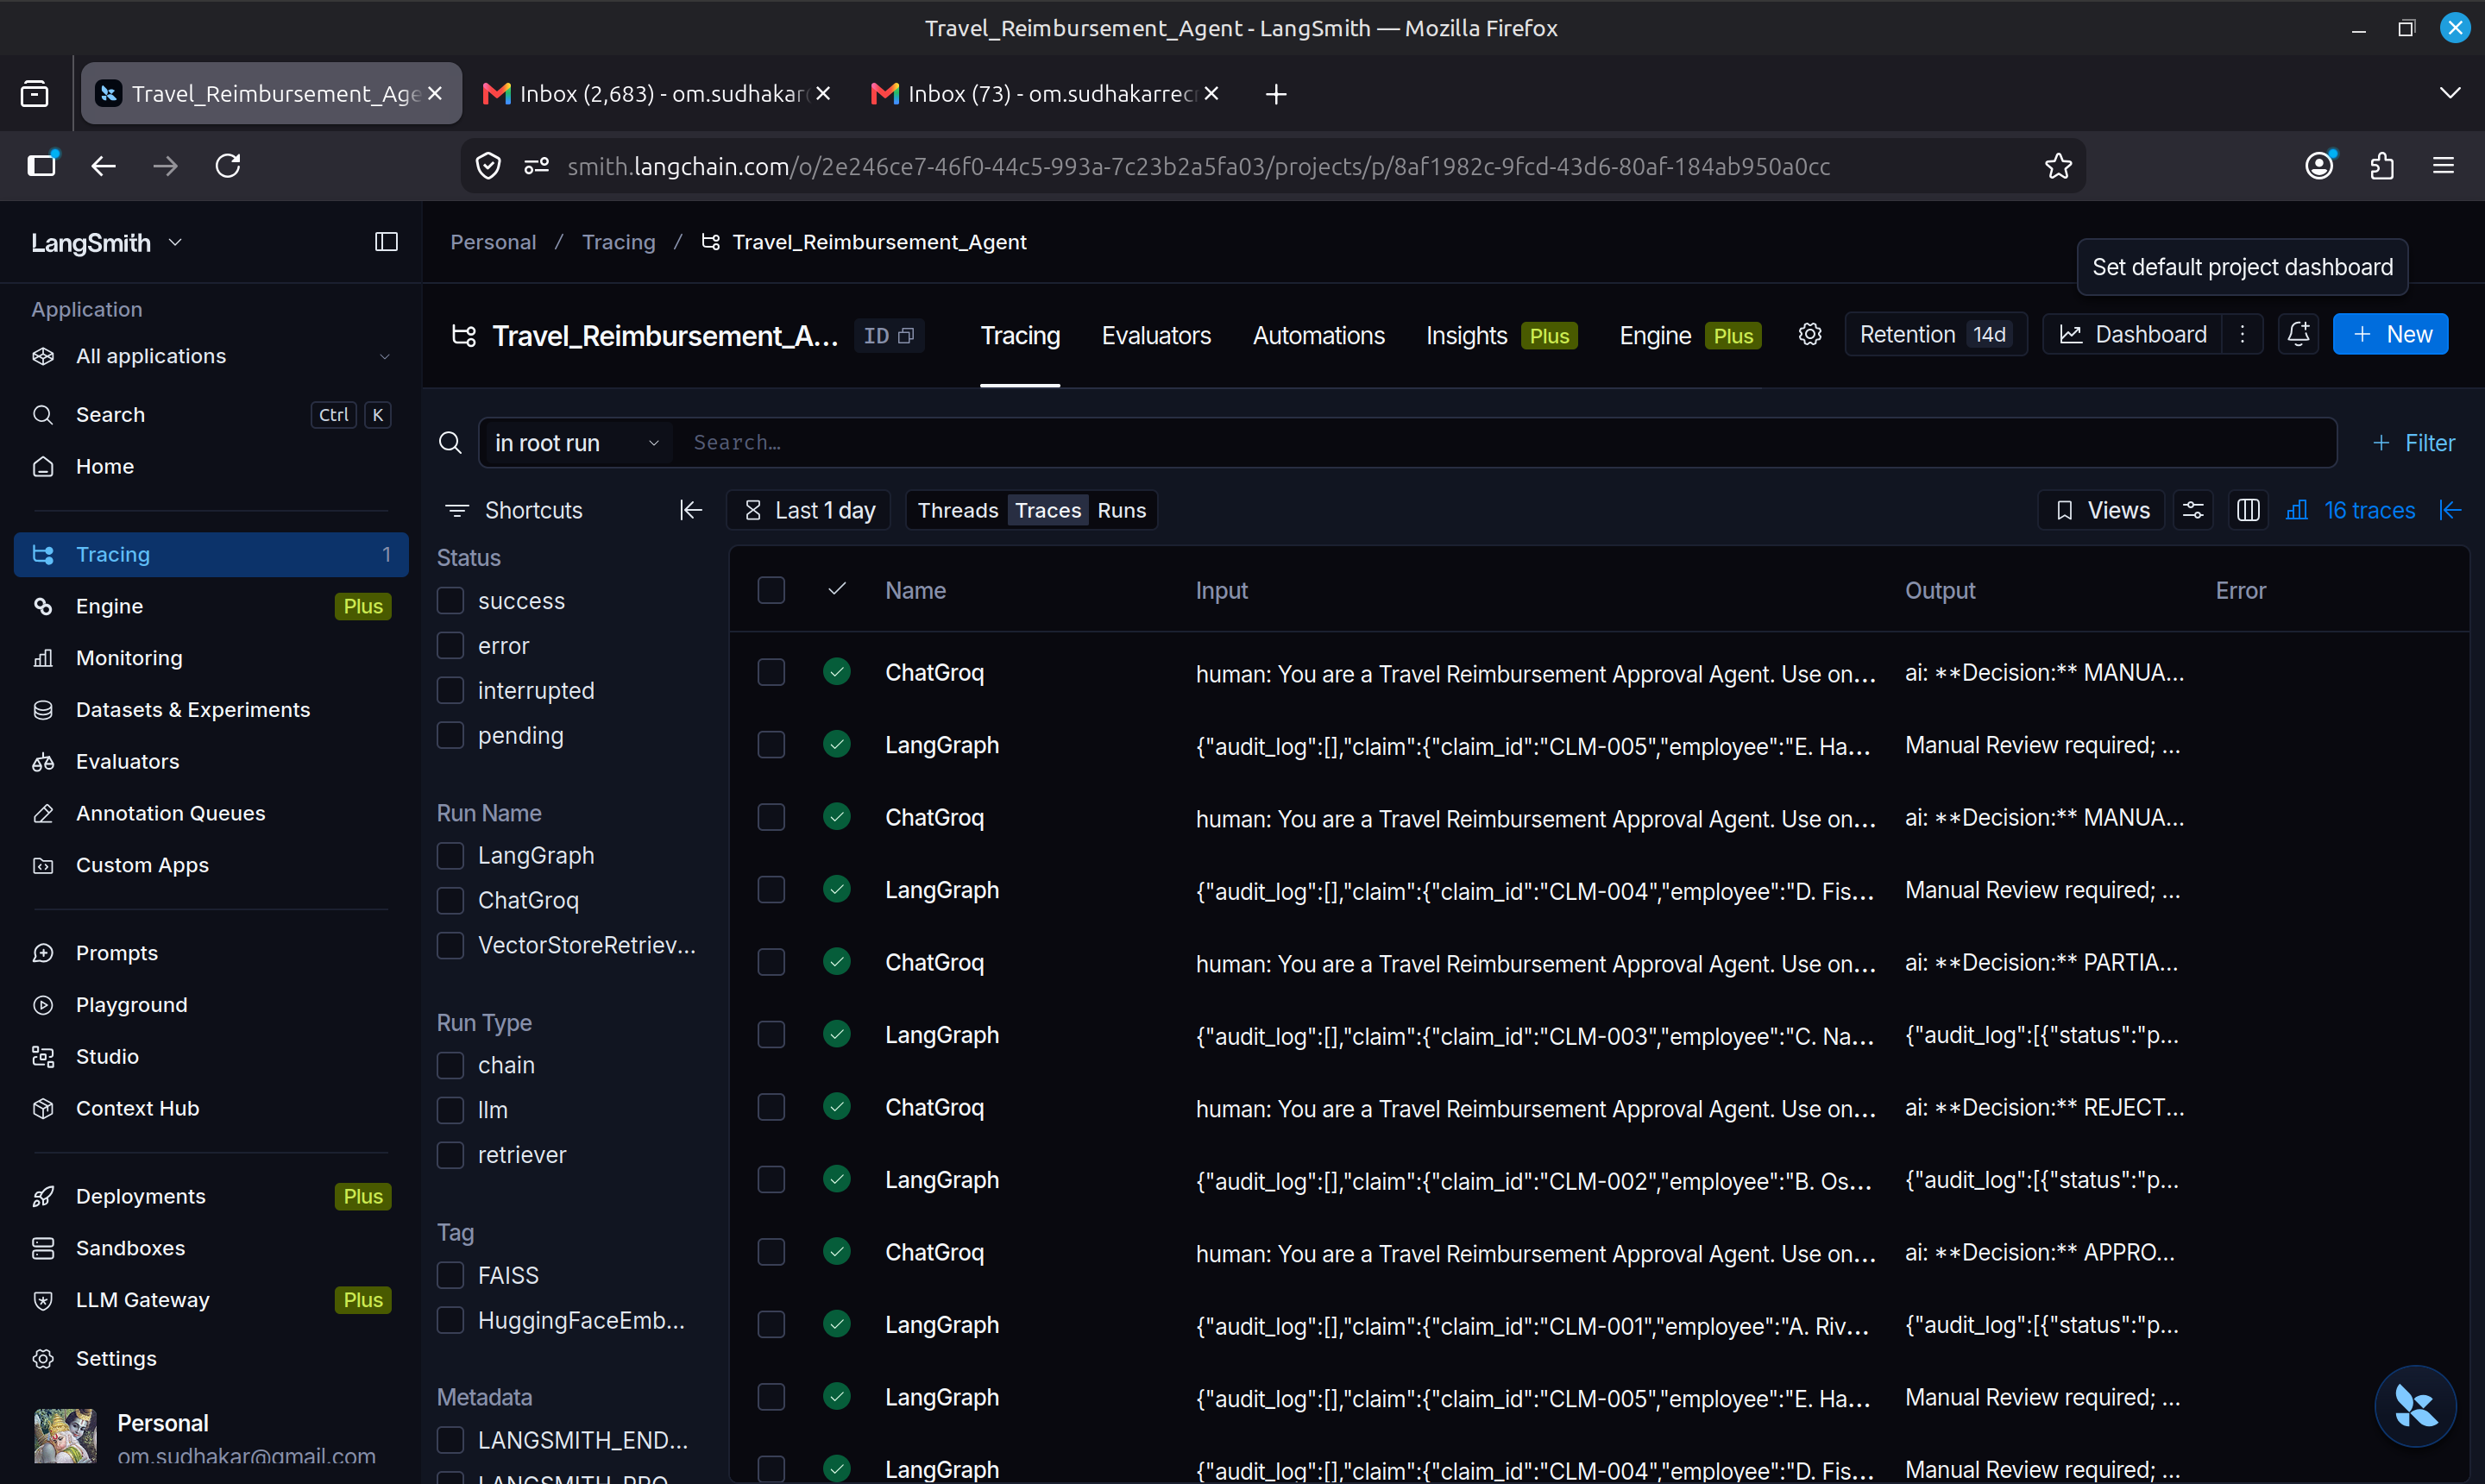

# UI: created using AI

In [ ]:
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import json

claim_lookup = {c["claim_id"]: c for c in claims}
claim_ids = [c["claim_id"] for c in claims]

claim_selector = widgets.Dropdown(
    options=claim_ids,
    value=claim_ids[0] if claim_ids else None,
    description="Claim:",
    layout=widgets.Layout(width="300px")
)

evaluate_button = widgets.Button(
    description="Evaluate Claim",
    button_style="primary",
    icon="check"
)

review_notes = widgets.Textarea(
    value="",
    placeholder="Optional reviewer note for a Manual Review case...",
    description="Review note:",
    layout=widgets.Layout(width="700px", height="80px")
)

output = widgets.Output()

def money(value):
    return f"${float(value):,.2f}"

def render_result(claim, result, audit_log):
    decision = result["decision"]
    decision_html = {
        "APPROVE": "<span style='font-size:20px;font-weight:700;'>APPROVE</span>",
        "PARTIAL_APPROVE": "<span style='font-size:20px;font-weight:700;'>PARTIAL_APPROVE</span>",
        "REJECT": "<span style='font-size:20px;font-weight:700;'>REJECT</span>",
        "MANUAL_REVIEW": "<span style='font-size:20px;font-weight:700;'>MANUAL_REVIEW</span>",
    }[decision]

    items_html = "".join(
        f"<tr><td>{i['category']}</td><td>{i['description']}</td>"
        f"<td>{money(i['amount'])}</td><td>{'Yes' if i['receipt'] else 'No'}</td></tr>"
        for i in claim["items"]
    )

    missing = ", ".join(result["missing_docs"]) if result["missing_docs"] else "None"
    refs = ", ".join(result["policy_refs"]) if result["policy_refs"] else "None"
    tools = ", ".join(result["tools_used"])
    human = "YES" if decision == "MANUAL_REVIEW" else "NO"

    html = f"""
    <div style='font-family:Arial,sans-serif;max-width:950px;'>
      <h3>Travel Reimbursement Approval Agent</h3>
      <table style='width:100%;border-collapse:collapse;'>
        <tr><td><b>Claim ID</b></td><td>{claim['claim_id']}</td>
            <td><b>Employee</b></td><td>{claim.get('employee','')}</td></tr>
        <tr><td><b>Trip</b></td><td>{claim.get('trip_start','')} → {claim.get('trip_end','')}</td>
            <td><b>Submitted</b></td><td>{claim.get('submitted','')}</td></tr>
        <tr><td><b>Total Claimed</b></td><td>{money(claim.get('total_claimed',0))}</td>
            <td><b>Human Review</b></td><td>{human}</td></tr>
      </table>

      <h4>Claim Items</h4>
      <table style='width:100%;border-collapse:collapse;'>
        <tr><th>Category</th><th>Description</th><th>Amount</th><th>Receipt</th></tr>
        {items_html}
      </table>

      <h4>Agent Decision</h4>
      <p><b>Decision:</b> {decision_html}</p>
      <table style='width:100%;border-collapse:collapse;'>
        <tr><td><b>Approved Amount</b></td><td>{money(result['approved_amount'])}</td>
            <td><b>Deducted Amount</b></td><td>{money(result['deducted_amount'])}</td></tr>
        <tr><td><b>Confidence</b></td><td>{result['confidence']:.2f}</td>
            <td><b>Missing Documents</b></td><td>{missing}</td></tr>
      </table>

      <h4>Policy References</h4>
      <p>{refs}</p>

      <h4>Explanation</h4>
      <p>{result['explanation']}</p>

      <h4>Tools Used</h4>
      <p>{tools}</p>
    </div>
    """
    display(HTML(html))

    print("\nRequired JSON output for this claim:")
    print(json.dumps(result, indent=2))

    print("\nAudit trail:")
    for event in audit_log:
        print(json.dumps(event, indent=2))


def on_evaluate(_):
    with output:
        clear_output(wait=True)
        claim = claim_lookup[claim_selector.value]

        # Invoke the same LangGraph workflow used for the assignment evaluation.
        state = graph.invoke({
            "claim": claim,
            "audit_log": [],
            "human_feedback": review_notes.value.strip() or None
        })

        result = state["final_decision"]
        render_result(claim, result, state.get("audit_log", []))

evaluate_button.on_click(on_evaluate)

display(widgets.VBox([
    widgets.HTML("<h2>Interactive Travel Reimbursement Approval Agent</h2>"),
    widgets.HTML("Select a claim and run the existing LangGraph agent. For Manual Review cases, an optional reviewer note can be supplied."),
    widgets.HBox([claim_selector, evaluate_button]),
    review_notes,
    output
]))


# Tech stack choices :

### LangGraph
The workflow has explicit stages, conditional routing and a Manual Review boundary.

### RAG
The decision is grounded in the supplied reimbursement policy. Policy IDs such as
`POL-*` are retained in Pinecone metadata so retrieved evidence is auditable.

### Pinecone
Pinecone provides a managed, persistent vector database for semantic policy retrieval.
The LangChain `PineconeVectorStore` interface keeps the retrieval layer separate from
the LangGraph business logic.

### Deterministic tools
Arithmetic, category limits, dates and receipt requirements are deterministic business
rules and should not be delegated to an LLM.

### HITL (Human in the loop)
The policy requires Manual Review for missing required receipts, business/first-class
airfare, high-value claims, late claims and ambiguity.

### Structured output using Pydantic
Pydantic enforces the exact output contract requested by the assignment.

### LangSmith
LangSmith provides observability for debugging and audit/trace demonstration.


# Further improvements

### Areas for Improvement / Production-Grade Enhancements

1. **Pinecone Vector Database**
   This implementation already uses Pinecone for persistent semantic retrieval.
   For production, configure appropriate namespaces, metadata filters, index sizing,
   access controls, monitoring, and lifecycle policies.

2. **Use an Alternative LLM for Lower Latency**
   The current implementation uses the Groq API with a free-tier LLM. For production,
   evaluate models/providers based on latency, reliability, cost and required quality.

3. **Evaluate Alternative Embedding Models**
   The current implementation uses `BAAI/bge-small-en-v1.5`. It can be replaced with
   another embedding model if retrieval quality or multilingual requirements demand it.
   The Pinecone index dimension must match the selected embedding model.

4. **Implement a Centralized Logging Module**
   A dedicated logging module should capture application events, errors, warnings and
   debugging information for production monitoring and troubleshooting.

5. **Convert the Jupyter Notebook into Modular Python Code**
   Organize the application into modular `.py` files for policy ingestion, Pinecone
   retrieval, deterministic rules, LangGraph orchestration, LLM interaction and API/UI
   handling. This improves maintainability, testing and deployment readiness.
